# 72-hour SHARP probability calibration

**Notebook 02 · Bamidele Akinwumi · exploratory candidate-label experiment**

Keep the trained GRU ensemble and logistic reference frozen. Fit and compare raw, logistic/Platt and isotonic probabilities using earlier data; then evaluate the locked methods on Cycle 25 and supplementary 2026. Actual results and reliability figures are saved below.

## Context and methods

1. Fit candidate calibrators on eligible July–November 2014 cases.
2. Select separately for each backbone on December 2014, using Brier score, then log loss, then the fixed method order to break ties. The raw identity map is a candidate.
3. Refit the prespecified methods on the full eligible July–December calibration block. Save the selected method before evaluation.
4. Evaluate all locked candidates on the existing retrospective/supplementary blocks. Never change the choice using these results.

### Key assumptions

- Target: the same science-class M/X start within 72 hours for the primary NOAA region. Labels remain provisional, and counts below are forecast windows, not independent flare events.
- Purge outcome windows plus an assumed 24-hour reporting delay at the internal selection boundary.
- Platt-style mapping: unpenalized logistic regression of outcome on the raw probability's logit, clipped at `1e-6`. Isotonic uses increasing regression and endpoint clipping outside fitted score support.
- Reliability uses ten fixed equal-width bins; ECE depends on these bins. Empty bins remain undefined.
- Calibration intercept/slope are jointly estimated descriptive diagnostics on each evaluation block. They never alter the issued probabilities.
- Paired Brier intervals use 1,000 resamples of mapped region components, plus an epoch-anchored seven-day UTC block sensitivity. These are conditional, per-comparison percentile intervals, not simultaneous guarantees or independent validation.
- Conformal-calibration and policy-development blocks remain reserved.

**Required input:** the frozen result directory from notebook 01, and the matching dataset package. This notebook does not retrain the backbones or download AIA. A different training result requires its own pinned configuration, rather than bypassing the integrity checks.

## 1. Environment and paths

Use the project's training kernel with `requirements-notebook.txt`. For another environment, install the listed packages and set the source/data paths below. Execution was verified locally; cloud execution is not claimed.

In [1]:
# Optional setup for a fresh notebook environment. Restart afterwards if packages were already loaded.
INSTALL_DEPENDENCIES = False
if INSTALL_DEPENDENCIES:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy==2.3.5', 'pandas==2.2.3',
                           'scikit-learn==1.7.2', 'scipy==1.16.3', 'matplotlib==3.10.7'])

from datetime import datetime, timezone
import hashlib
import json
import os
from pathlib import Path
import tempfile
import warnings

import numpy as np
import pandas as pd
import scipy
from scipy.special import expit, logit
import sklearn
from sklearn.exceptions import ConvergenceWarning
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from IPython.display import display, Markdown

WORKSPACE = Path.cwd()
if WORKSPACE.name == 'notebooks':
    WORKSPACE = WORKSPACE.parent
print({'numpy': np.__version__, 'pandas': pd.__version__, 'scipy': scipy.__version__, 'sklearn': sklearn.__version__})

{'numpy': '2.3.5', 'pandas': '2.2.3', 'scipy': '1.16.3', 'sklearn': '1.7.2'}


In [2]:
CONFIG = json.loads(r'''{
  "experiment": "sharp72_calibration_candidate_v1",
  "training_dir": "outputs/sharp72_notebook_v1_20261002T080801721986Z",
  "training_summary_sha256": "e6418e5aac60a4ef7641ff32cd5c1b1b282db1e2b88af0a6f6aebc79a62058d0",
  "prediction_sha256": "7368c002a978321cdc67221564f3b7901687badc7aba28ab9df615179d1e017b",
  "dataset_manifest_sha256": "7bb88614482cacd5fafb145d88345132a6cf97b25b8313dbefd90b08ac5b9d27",
  "horizon": 72,
  "scope": "primary",
  "calibration_start": "2014-07-01",
  "inner_selection_start": "2014-12-01",
  "calibration_end": "2015-01-01",
  "reporting_delay_hours": 24,
  "candidate_methods": [
    "raw",
    "platt",
    "isotonic"
  ],
  "selection": "lowest inner December Brier, then log loss, then declared method order",
  "final_fit": "refit all prespecified candidates on the entire earlier probability_calibration block",
  "logit_clip_epsilon": 1e-06,
  "log_loss_clip_epsilon": 1e-12,
  "reliability_bins": 10,
  "bootstrap_repetitions": 1000,
  "bootstrap_seed": 2718,
  "bootstrap_groups": [
    "region_component",
    "calendar_7day_UTC"
  ],
  "bootstrap_contrast": "paired Brier(method) minus Brier(raw); 95% percentile intervals",
  "evaluation_roles": [
    "retrospective_cycle25",
    "supplementary_2026"
  ]
}''')
TRAINING_DIR = WORKSPACE / CONFIG['training_dir']
DATASET_DIR = WORKSPACE / 'data/processed/training_snapshot_20261002/gray_box_aligned_v1'
OUTPUT_DIR = WORKSPACE / 'outputs' / ('sharp72_calibration_v1_' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ'))
print('Frozen training:', TRAINING_DIR)
print('New calibration run:', OUTPUT_DIR)
display(pd.DataFrame([
    {'Stage': 'Inner fit', 'Start': '2014-07-01', 'End (exclusive)': '2014-12-01'},
    {'Stage': 'Method selection', 'Start': '2014-12-01', 'End (exclusive)': '2015-01-01'},
    {'Stage': 'Final calibration refit', 'Start': '2014-07-01', 'End (exclusive)': '2015-01-01'}]))

Frozen training: /Users/mac/Documents/ChatGPT/Imaging_Project/gray-box-solar-flare-forecasting/outputs/sharp72_notebook_v1_20261002T080801721986Z
New calibration run: /Users/mac/Documents/ChatGPT/Imaging_Project/gray-box-solar-flare-forecasting/outputs/sharp72_calibration_v1_20261002T083245963780Z


,Stage,Start,End (exclusive)
0,Inner fit,2014-07-01,2014-12-01
1,Method selection,2014-12-01,2015-01-01
2,Final calibration refit,2014-07-01,2015-01-01


## 2. Verify the frozen model outputs and target data

In [3]:
def sha256(path):
    with Path(path).open("rb") as stream:
        return hashlib.file_digest(stream, "sha256").hexdigest()

def save_json(path, value):
    Path(path).write_text(json.dumps(value, indent=2, allow_nan=False) + "\n")

def check_probabilities(p, y=None):
    p = np.asarray(p, dtype=float)
    if p.ndim != 1 or not len(p) or not np.isfinite(p).all() or ((p < 0) | (p > 1)).any():
        raise ValueError("Need a nonempty vector of finite probabilities in [0,1]")
    if y is not None and (np.shape(y) != p.shape or not np.isin(y, [0, 1]).all()):
        raise ValueError("Unknown outcomes must not enter calibration or metrics")
    return p

def load_sources(training_dir, dataset, config):
    if sha256(training_dir / "summary.json") != config["training_summary_sha256"] or sha256(training_dir / "predictions.csv.gz") != config["prediction_sha256"]:
        raise ValueError("Frozen training result changed")
    summary = json.loads((training_dir / "summary.json").read_text())
    if summary["horizon"] != 72 or summary["scope"] != "primary" or config["horizon"] != 72 or config["scope"] != "primary":
        raise ValueError("This experiment requires the pinned 72h primary target")
    for name, expected in summary["output_sha256"].items():
        if sha256(training_dir / name) != expected:
            raise ValueError(f"Frozen training artifact changed: {name}")
    if sha256(dataset / "manifest.json") != config["dataset_manifest_sha256"]:
        raise ValueError("Dataset manifest changed")
    manifest = json.loads((dataset / "manifest.json").read_text())
    if sha256(dataset / "master_cases.csv.gz") != manifest["outputs"]["master_cases.csv.gz"]["sha256"]:
        raise ValueError("Master-case table changed")
    master = pd.read_csv(dataset / "master_cases.csv.gz", low_memory=False)
    predictions = pd.read_csv(training_dir / "predictions.csv.gz")
    frame = predictions.merge(master[["forecast_case_id", "outcome_end_utc_72h", "candidate_primary_label_72h"]],
                              on="forecast_case_id", how="left", validate="one_to_one")
    if frame.forecast_case_id.duplicated().any() or frame.outcome_end_utc_72h.isna().any():
        raise ValueError("Case identities are incomplete")
    if not np.array_equal(frame.label, frame.candidate_primary_label_72h.fillna(-1)) or not np.array_equal(frame.label_known, frame.label.ne(-1)):
        raise ValueError("Frozen predictions and source labels disagree")
    return frame, master, summary

## 3. Fit and serialize calibration maps

Calibrators are saved as plain JSON parameters. Their restored predictions are checked against the fitted scikit-learn estimator.

In [4]:
def apply_calibrator(p, parameters):
    p = check_probabilities(p)
    method = parameters["method"]
    if method == "raw":
        return p.copy()
    if method == "platt":
        epsilon = parameters["epsilon"]
        return expit(parameters["intercept"] + parameters["slope"] * logit(np.clip(p, epsilon, 1-epsilon)))
    if method == "isotonic":
        return np.interp(p, parameters["x"], parameters["y"])
    raise ValueError("Unknown calibration method")

def fit_calibrator(p, y, method, epsilon=1e-6):
    p = check_probabilities(p, y)
    y = np.asarray(y, dtype=int)
    if set(np.unique(y)) != {0, 1}:
        raise ValueError("Both outcome classes are required for fitting")
    if method == "raw":
        return {"method": "raw"}
    if method == "platt":
        x = logit(np.clip(p, epsilon, 1-epsilon)).reshape(-1, 1)
        model = LogisticRegression(penalty=None, solver="lbfgs", max_iter=2000, tol=1e-10)
        with warnings.catch_warnings():
            warnings.simplefilter("error", ConvergenceWarning)
            model.fit(x, y)
        parameters = {"method": "platt", "intercept": float(model.intercept_[0]),
                      "slope": float(model.coef_[0, 0]), "epsilon": epsilon}
        expected = model.predict_proba(x)[:, 1]
    elif method == "isotonic":
        model = IsotonicRegression(increasing=True, out_of_bounds="clip").fit(p, y)
        parameters = {"method": "isotonic", "x": model.X_thresholds_.tolist(), "y": model.y_thresholds_.tolist()}
        expected = model.predict(p)
    else:
        raise ValueError("Unknown calibration method")
    restored = json.loads(json.dumps(parameters))
    np.testing.assert_allclose(apply_calibrator(p, restored), expected, rtol=1e-12, atol=1e-12)
    return parameters

## 4. Reliability, probability scores and earlier-data selection

In [5]:
def reliability_table(y, p, bins=10):
    p = check_probabilities(p, y)
    y = np.asarray(y, dtype=int)
    edges = np.linspace(0, 1, bins+1)
    membership = np.minimum(np.searchsorted(edges, p, side="right")-1, bins-1)
    rows = []
    for i in range(bins):
        selected = membership == i
        n = int(selected.sum())
        rows.append({"bin": i, "left": edges[i], "right": edges[i+1], "count": n,
                     "positive": int(y[selected].sum()),
                     "mean_probability": float(p[selected].mean()) if n else None,
                     "observed_fraction": float(y[selected].mean()) if n else None})
    return pd.DataFrame(rows)

def score_probabilities(y, p, climatology, config, diagnostics=True):
    p = check_probabilities(p, y)
    y = np.asarray(y, dtype=int)
    epsilon = config["log_loss_clip_epsilon"]
    clipped = np.clip(p, epsilon, 1-epsilon)
    bins = reliability_table(y, p, config["reliability_bins"])
    brier = float(np.mean((p-y)**2))
    reference = float(np.mean((climatology-y)**2))
    result = {"cases": len(y), "positive": int(y.sum()), "prevalence": float(y.mean()),
              "brier": brier, "brier_skill_train_climatology": 1-brier/reference if reference else None,
              "log_loss": float(-np.mean(y*np.log(clipped)+(1-y)*np.log1p(-clipped))),
              "ece_equal_width_10": float((bins["count"] * (bins.mean_probability-bins.observed_fraction).abs()).sum()/len(y))}
    if diagnostics:
        try:
            diagnostic = fit_calibrator(p, y, "platt", config["logit_clip_epsilon"])
            result.update(calibration_intercept=diagnostic["intercept"], calibration_slope=diagnostic["slope"],
                          calibration_diagnostic_status="joint_unpenalized_logistic_fit_descriptive_only")
        except (ValueError, ConvergenceWarning):
            result.update(calibration_intercept=None, calibration_slope=None, calibration_diagnostic_status="undefined_or_nonconverged")
    return result

def calibration_masks(frame, config):
    issue = pd.to_datetime(frame.issue_utc, utc=True, format="ISO8601")
    mature = pd.to_datetime(frame.outcome_end_utc_72h, utc=True, format="ISO8601") + pd.Timedelta(hours=config["reporting_delay_hours"])
    start, cut, stop = (pd.Timestamp(config[key], tz="UTC") for key in ("calibration_start", "inner_selection_start", "calibration_end"))
    eligible = frame.role.eq("probability_calibration") & frame.label.isin([0, 1]) & frame.label_known
    if (eligible & ~((issue >= start) & (issue < stop) & (mature <= stop))).any():
        raise ValueError("Calibration role violates its frozen information boundary")
    fit = eligible & (issue < cut) & (mature <= cut)
    selection = eligible & (issue >= cut)
    if not start < cut < stop or (fit & selection).any():
        raise ValueError("Invalid internal calibration boundaries")
    for selected in (fit, selection):
        if set(frame.loc[selected, "label"].unique()) != {0, 1}:
            raise ValueError("Both classes required in inner fitting and method-selection blocks")
    return eligible.to_numpy(), fit.to_numpy(), selection.to_numpy()

def select_and_refit(frame, config, climatology):
    eligible, fit, selection = calibration_masks(frame, config)
    choices, models, scores = {}, {}, []
    for model_name, column in (("gru", "probability_gru_mean"), ("logistic", "probability_logistic")):
        candidates = []
        for rank, method in enumerate(config["candidate_methods"]):
            parameters = fit_calibrator(frame.loc[fit, column].to_numpy(), frame.loc[fit, "label"].to_numpy(), method, config["logit_clip_epsilon"])
            p = apply_calibrator(frame.loc[selection, column].to_numpy(), parameters)
            score = score_probabilities(frame.loc[selection, "label"].to_numpy(), p, climatology, config, diagnostics=False)
            record = {"model": model_name, "method": method, **score}
            scores.append(record)
            candidates.append((score["brier"], score["log_loss"], rank, method))
        choices[model_name] = min(candidates)[-1]
        models[model_name] = {method: fit_calibrator(frame.loc[eligible, column].to_numpy(), frame.loc[eligible, "label"].to_numpy(), method, config["logit_clip_epsilon"])
                              for method in config["candidate_methods"]}
    support = {name: {"cases": int(mask.sum()), "positive": int(frame.loc[mask, "label"].sum())}
               for name, mask in (("inner_fit", fit), ("inner_selection", selection), ("full_final_fit", eligible),
                                  ("inner_boundary_purged", eligible & ~fit & ~selection))}
    return {"selected_methods": choices, "calibrators": models, "inner_scores": scores, "support": support}

## 5. Paired uncertainty and execution

A negative Brier difference favours the calibrated candidate over its own raw backbone. Components/blocks are resampled with all their included windows; methods stay paired on identical cases.

In [6]:
def paired_brier_bootstrap(y, candidate, raw, groups, repetitions=1000, seed=2718):
    check_probabilities(candidate, y)
    check_probabilities(raw, y)
    if pd.isna(groups).any():
        raise ValueError("Missing bootstrap group")
    delta = (np.asarray(candidate)-y)**2 - (np.asarray(raw)-y)**2
    grouped = pd.DataFrame({"group": groups, "delta": delta}).groupby("group", sort=True).delta.agg(["sum", "count"])
    count = len(grouped)
    if count < 2:
        return {"difference": float(delta.mean()), "low": None, "high": None, "groups": count}
    rng = np.random.default_rng(seed)
    weights = rng.multinomial(count, np.full(count, 1/count), size=repetitions)
    draws = (weights @ grouped["sum"].to_numpy()) / (weights @ grouped["count"].to_numpy())
    low, high = np.quantile(draws, [0.025, 0.975])
    return {"difference": float(delta.mean()), "low": float(low), "high": float(high), "groups": count}

def run_calibration(training_dir, dataset, config, output, source_code):
    if output.exists():
        raise ValueError("Choose a new result directory; frozen outputs are never overwritten")
    frame, master, parent = load_sources(training_dir, dataset, config)
    output.parent.mkdir(parents=True, exist_ok=True)
    staging = Path(tempfile.mkdtemp(prefix=output.name + ".incomplete-", dir=output.parent))
    try:
        selection = select_and_refit(frame, config, parent["train_climatology"])
        # Freeze the chosen method and final earlier-data fits before any evaluation.
        save_json(staging / "selection.json", selection)
        restored = json.loads((staging / "selection.json").read_text())
        evaluation, bins, intervals = [], [], []
        for model_name, column in (("gru", "probability_gru_mean"), ("logistic", "probability_logistic")):
            available = frame[column].notna()
            for method in config["candidate_methods"]:
                out_col = f"{model_name}_{method}"
                frame[out_col] = np.nan
                frame.loc[available, out_col] = apply_calibrator(frame.loc[available, column].to_numpy(), restored["calibrators"][model_name][method])
                for role in config["evaluation_roles"]:
                    selected = frame.role.eq(role) & frame.label_known & available
                    y = frame.loc[selected, "label"].to_numpy()
                    p = frame.loc[selected, out_col].to_numpy()
                    evaluation.append({"role": role, "model": model_name, "method": method,
                                       "selected_on_earlier_data": method == restored["selected_methods"][model_name],
                                       **score_probabilities(y, p, parent["train_climatology"], config)})
                    binned = reliability_table(y, p, config["reliability_bins"])
                    binned["role"], binned["model"], binned["method"] = role, model_name, method
                    bins.append(binned)
                    if method != "raw":
                        times = pd.to_datetime(frame.loc[selected, "issue_utc"], utc=True, format="ISO8601")
                        for scheme in config["bootstrap_groups"]:
                            groups = frame.loc[selected, "region_component_id"].to_numpy() if scheme == "region_component" else (times.astype("int64") // (7*86400*10**9)).to_numpy()
                            intervals.append({"role": role, "model": model_name, "method": method, "grouping": scheme,
                                **paired_brier_bootstrap(y, p, frame.loc[selected, column].to_numpy(), groups,
                                                        config["bootstrap_repetitions"], config["bootstrap_seed"])})
            frame[f"{model_name}_selected"] = frame[f"{model_name}_{restored['selected_methods'][model_name]}"]
        probabilities = [f"{model}_{method}" for model in ("gru", "logistic") for method in [*config["candidate_methods"], "selected"]]
        frame[["forecast_case_id", "issue_utc", "region_component_id", "role", "label", "label_known", *probabilities]].to_csv(
            staging / "calibrated_predictions.csv.gz", index=False, compression={"method": "gzip", "mtime": 0})
        population = master[["forecast_case_id", "issue_utc", "inputs_available", "candidate_primary_label_72h", "label_known_primary_72h"]].merge(
            frame[["forecast_case_id", *probabilities]], on="forecast_case_id", how="left", validate="one_to_one")
        population["forecast_status"] = np.where(population.gru_selected.notna(), "scored_exploratory", "no_supported_sharp_input")
        population.to_csv(staging / "population_predictions.csv.gz", index=False, compression={"method": "gzip", "mtime": 0})
        pd.DataFrame(evaluation).to_csv(staging / "metrics.csv", index=False)
        pd.concat(bins, ignore_index=True).to_csv(staging / "reliability.csv", index=False)
        pd.DataFrame(intervals).to_csv(staging / "paired_brier_intervals.csv", index=False)
        save_json(staging / "run_contract.json", {"config": config, "source_code_sha256": hashlib.sha256(source_code.encode()).hexdigest(),
            "versions": {"numpy": np.__version__, "pandas": pd.__version__, "scipy": scipy.__version__, "sklearn": sklearn.__version__}})
        (staging / "executed_calibration_code.py").write_text(source_code)
        summary = {"status": "completed_exploratory_calibration", "completed_utc": datetime.now(timezone.utc).isoformat(),
            "selected_methods": restored["selected_methods"], "support": restored["support"], "metrics": evaluation,
            "population_rows": len(population), "unscored_rows": int(population.gru_selected.isna().sum()),
            "backbone_refitted": False, "conformal_or_policy_fitted": False,
            "limitations": ["Candidate source labels and unknown-outcome exclusions remain provisional.",
                "Selection is based on one earlier calendar block; it is not guaranteed to transfer across cycles.",
                "Lower Brier loss is not, on its own, proof of better calibration.",
                "Calibration intercept/slope fitted on evaluation labels are descriptive diagnostics only; they never modify forecasts.",
                "Bootstrap intervals are paired group-resampling sensitivities conditional on these frozen models and labels, not independent validation or simultaneous intervals.",
                "Previously inspected Cycle-25/2026 data remain retrospective/supplementary, not prospective confirmation.",
                "Conformal and policy blocks remain reserved; no operational trust-state policy has been validated."],
            "output_sha256": {p.name: sha256(p) for p in staging.iterdir()}}
        save_json(staging / "summary.json", summary)
        if output.exists():
            raise ValueError("Output appeared during execution")
        staging.rename(output)
        return summary
    except Exception as exc:
        save_json(staging / "failure.json", {"error": str(exc), "incomplete_run": True})
        raise

In [7]:
executed_code = '\n\n'.join(get_ipython().history_manager.input_hist_raw)
summary = run_calibration(TRAINING_DIR, DATASET_DIR, CONFIG, OUTPUT_DIR, executed_code)
selection = json.loads((OUTPUT_DIR / 'selection.json').read_text())
print(summary['status'])
print('Backbone refitted:', summary['backbone_refitted'])
display(pd.DataFrame(selection['support']).T.rename(columns={'cases': 'Windows', 'positive': 'Positive windows'}))
display(Markdown('**Frozen choices:** ' + '; '.join(f"{model}: **{method}**" for model, method in selection['selected_methods'].items())))

completed_exploratory_calibration
Backbone refitted: False


,Windows,Positive windows
inner_fit,1900,76
inner_selection,764,98
full_final_fit,2831,184
inner_boundary_purged,167,10


**Frozen choices:** gru: **raw**; logistic: **raw**

## 6. Selection evidence from December 2014

This table controls the chosen method. Later evaluation tables are descriptive and do not change the selection.

In [8]:
inner = pd.DataFrame(selection['inner_scores'])
inner['Selected'] = [method == selection['selected_methods'][model] for model, method in zip(inner.model, inner.method)]
display(inner[['model', 'method', 'cases', 'positive', 'brier', 'log_loss', 'Selected']]
        .rename(columns={'model': 'Model', 'method': 'Method', 'cases': 'Windows', 'positive': 'Positive windows',
                         'brier': 'Brier', 'log_loss': 'Log loss'}).round(6))

,Model,Method,Windows,Positive windows,Brier,Log loss,Selected
0,gru,raw,764,98,0.062285,0.216397,True
1,gru,platt,764,98,0.087041,0.284485,False
2,gru,isotonic,764,98,0.080173,0.609258,False
3,logistic,raw,764,98,0.071429,0.238457,True
4,logistic,platt,764,98,0.090828,0.300187,False
5,logistic,isotonic,764,98,0.087709,0.635174,False


## 7. Frozen evaluation results

Brier skill compares against the training-fitted climatology. A lower Brier score alone does not establish improved calibration; inspect reliability and support alongside it.

In [9]:
metrics = pd.read_csv(OUTPUT_DIR / 'metrics.csv')
period_names = {'retrospective_cycle25': 'Cycle 25: 2021–25', 'supplementary_2026': '2026: supplementary'}
readable = metrics.copy()
readable['role'] = readable.role.replace(period_names)
readable = readable.rename(columns={'role': 'Period', 'model': 'Model', 'method': 'Method',
    'selected_on_earlier_data': 'Selected', 'brier': 'Brier', 'brier_skill_train_climatology': 'Brier skill',
    'log_loss': 'Log loss', 'ece_equal_width_10': 'ECE', 'calibration_intercept': 'Intercept', 'calibration_slope': 'Slope'})
display(readable[['Period', 'Model', 'Method', 'Selected', 'Brier', 'Brier skill', 'Log loss']].round(6))
display(readable[['Period', 'Model', 'Method', 'ECE', 'Intercept', 'Slope']].round(4))

,Period,Model,Method,Selected,Brier,Brier skill,Log loss
0,Cycle 25: 2021–25,gru,raw,True,0.077365,0.215263,0.267044
1,2026: supplementary,gru,raw,True,0.069099,0.159970,0.281478
2,Cycle 25: 2021–25,gru,platt,False,0.078457,0.204186,0.273704
3,2026: supplementary,gru,platt,False,0.070414,0.143985,0.288472
4,Cycle 25: 2021–25,gru,isotonic,False,0.084477,0.143123,0.444994
5,2026: supplementary,gru,isotonic,False,0.069486,0.155270,0.635821
6,Cycle 25: 2021–25,logistic,raw,True,0.077341,0.215504,0.267016
7,2026: supplementary,logistic,raw,True,0.069042,0.160668,0.289493
8,Cycle 25: 2021–25,logistic,platt,False,0.078814,0.200566,0.275293
9,2026: supplementary,logistic,platt,False,0.070384,0.144350,0.301196


,Period,Model,Method,ECE,Intercept,Slope
0,Cycle 25: 2021–25,gru,raw,0.0307,-0.0863,0.7542
1,2026: supplementary,gru,raw,0.0474,-0.0223,0.6559
2,Cycle 25: 2021–25,gru,platt,0.0392,0.3178,0.8312
3,2026: supplementary,gru,platt,0.0517,0.3292,0.7229
4,Cycle 25: 2021–25,gru,isotonic,0.0578,-0.8932,0.2960
5,2026: supplementary,gru,isotonic,0.0503,-1.0954,0.1986
6,Cycle 25: 2021–25,logistic,raw,0.0289,-0.0467,0.7550
7,2026: supplementary,logistic,raw,0.0436,-0.2300,0.5530
8,Cycle 25: 2021–25,logistic,platt,0.0395,0.1695,0.7612
9,2026: supplementary,logistic,platt,0.0510,-0.0717,0.5575


## 8. Reliability and bin support

The diagonal is ideal reliability. Curves show mean forecast probability versus observed candidate-event fraction within each bin. The lower panels show the number of windows behind those points; sparse bins are not precise estimates. No independent-bin confidence intervals are asserted.

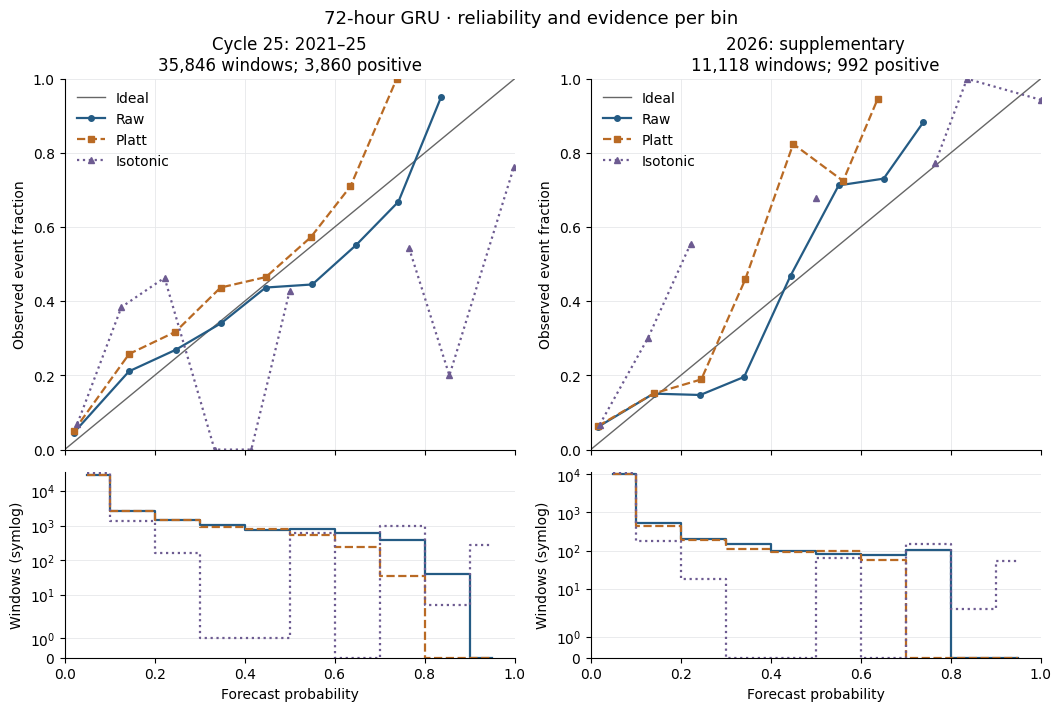

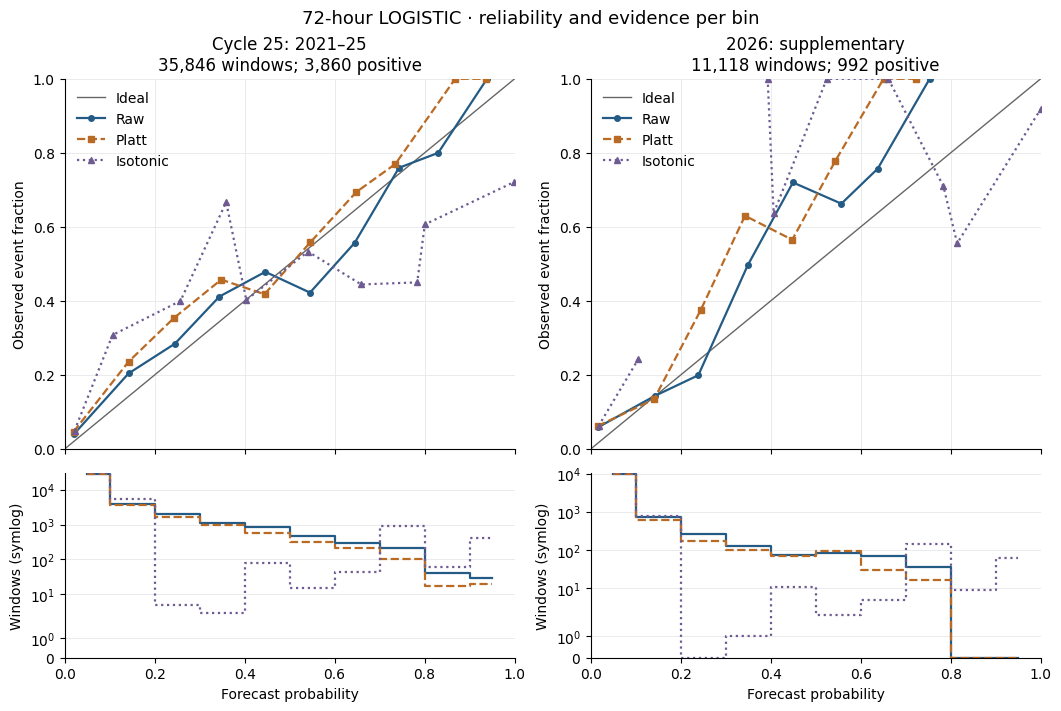

In [10]:
os.environ.setdefault('MPLCONFIGDIR', str(WORKSPACE / 'outputs' / '.matplotlib'))
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.facecolor': 'white', 'axes.facecolor': 'white'})
reliability = pd.read_csv(OUTPUT_DIR / 'reliability.csv')
styles = {'raw': ('#245B84', 'o', '-'), 'platt': ('#B96A24', 's', '--'), 'isotonic': ('#6D5B91', '^', ':')}
for model in ['gru', 'logistic']:
    fig, axes = plt.subplots(2, 2, figsize=(10.5, 7), sharex='col',
                             gridspec_kw={'height_ratios': [2, 1]}, constrained_layout=True)
    for column, role in enumerate(CONFIG['evaluation_roles']):
        evidence = metrics[(metrics.model == model) & (metrics.role == role)].iloc[0]
        axes[0, column].plot([0, 1], [0, 1], color='#666666', linewidth=1, label='Ideal')
        for method, (color, marker, line) in styles.items():
            subset = reliability[(reliability.model == model) & (reliability.role == role) & (reliability.method == method)]
            axes[0, column].plot(subset.mean_probability, subset.observed_fraction, color=color, marker=marker,
                                 linestyle=line, linewidth=1.6, markersize=4, label=method.capitalize())
            axes[1, column].step((subset.left + subset.right)/2, subset['count'], where='mid',
                                 color=color, linestyle=line, linewidth=1.6)
        axes[0, column].set(title=f"{period_names[role]}\n{int(evidence.cases):,} windows; {int(evidence.positive):,} positive",
                            xlim=(0, 1), ylim=(0, 1), ylabel='Observed event fraction')
        axes[0, column].legend(frameon=False, loc='upper left')
        axes[1, column].set(yscale='symlog', xlabel='Forecast probability', ylabel='Windows (symlog)')
        axes[1, column].set_ylim(bottom=0)
        axes[0, column].grid(color='#E6E8EA', linewidth=0.6)
        axes[1, column].grid(axis='y', color='#E6E8EA', linewidth=0.6)
    fig.suptitle(f"72-hour {model.upper()} · reliability and evidence per bin", fontsize=13)
    fig.savefig(OUTPUT_DIR / f'reliability_{model}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. Paired Brier differences and checks

Intervals compare each prespecified candidate with its own raw probabilities. They are 95% percentile intervals for each contrast, with no correction for multiple comparisons. They do not include uncertainty in the labels, calibration-method selection or training process.

In [11]:
intervals = pd.read_csv(OUTPUT_DIR / 'paired_brier_intervals.csv')
for scheme in CONFIG['bootstrap_groups']:
    display(Markdown(f'**Resampling unit: {scheme}**'))
    table = intervals[intervals.grouping == scheme].copy()
    table['role'] = table.role.replace(period_names)
    display(table[['role', 'model', 'method', 'difference', 'low', 'high', 'groups']]
            .rename(columns={'role': 'Period', 'model': 'Model', 'method': 'Method', 'difference': 'Brier difference',
                             'low': '95% lower', 'high': '95% upper', 'groups': 'Groups'}).round(6))
for name, expected in summary['output_sha256'].items():
    assert sha256(OUTPUT_DIR / name) == expected, f'Changed calibration output: {name}'
parent = json.loads((TRAINING_DIR / 'summary.json').read_text())
for name, expected in parent['output_sha256'].items():
    assert sha256(TRAINING_DIR / name) == expected, f'Backbone artifact changed: {name}'
print('Calibration outputs verified; all frozen backbone artifacts remain unchanged.')
print('Full population:', summary['population_rows'], '| Missing-input cases without scores:', summary['unscored_rows'])

**Resampling unit: region_component**

,Period,Model,Method,Brier difference,95% lower,95% upper,Groups
0,Cycle 25: 2021–25,gru,platt,0.001092,-0.001134,0.003162,943
2,2026: supplementary,gru,platt,0.001315,-0.001409,0.004509,128
4,Cycle 25: 2021–25,gru,isotonic,0.007112,0.004054,0.010408,943
6,2026: supplementary,gru,isotonic,0.000387,-0.002107,0.003297,128
8,Cycle 25: 2021–25,logistic,platt,0.001473,0.000148,0.002762,943
10,2026: supplementary,logistic,platt,0.001342,-0.000486,0.003464,128
12,Cycle 25: 2021–25,logistic,isotonic,0.011260,0.007661,0.014902,943
14,2026: supplementary,logistic,isotonic,0.002286,-0.000511,0.005901,128


**Resampling unit: calendar_7day_UTC**

,Period,Model,Method,Brier difference,95% lower,95% upper,Groups
1,Cycle 25: 2021–25,gru,platt,0.001092,-0.000886,0.003018,255
3,2026: supplementary,gru,platt,0.001315,-0.001206,0.004437,33
5,Cycle 25: 2021–25,gru,isotonic,0.007112,0.004299,0.010254,255
7,2026: supplementary,gru,isotonic,0.000387,-0.001837,0.003272,33
9,Cycle 25: 2021–25,logistic,platt,0.001473,0.000240,0.002678,255
11,2026: supplementary,logistic,platt,0.001342,-0.000251,0.003370,33
13,Cycle 25: 2021–25,logistic,isotonic,0.011260,0.007839,0.014712,255
15,2026: supplementary,logistic,isotonic,0.002286,-0.000485,0.005666,33


Calibration outputs verified; all frozen backbone artifacts remain unchanged.
Full population: 153366 | Missing-input cases without scores: 39933


## Takeaways and next step

In [12]:
messages = []
for model in ['gru', 'logistic']:
    method = summary['selected_methods'][model]
    messages.append(f'**{model.upper()}** retained **{method}** using the earlier selection block.')
    for role in CONFIG['evaluation_roles']:
        selected_score = metrics[(metrics.model == model) & (metrics.method == method) & (metrics.role == role)].iloc[0]
        raw_score = metrics[(metrics.model == model) & (metrics.method == 'raw') & (metrics.role == role)].iloc[0]
        messages.append(f"{period_names[role]}: selected Brier {selected_score.brier:.6f}, raw {raw_score.brier:.6f}; difference {selected_score.brier-raw_score.brier:+.6f}.")
display(Markdown('\n\n'.join(messages)))
display(Markdown('### Interpretation limits\n' + '\n'.join('- ' + item for item in summary['limitations'])))

**GRU** retained **raw** using the earlier selection block.

Cycle 25: 2021–25: selected Brier 0.077365, raw 0.077365; difference +0.000000.

2026: supplementary: selected Brier 0.069099, raw 0.069099; difference +0.000000.

**LOGISTIC** retained **raw** using the earlier selection block.

Cycle 25: 2021–25: selected Brier 0.077341, raw 0.077341; difference +0.000000.

2026: supplementary: selected Brier 0.069042, raw 0.069042; difference +0.000000.

### Interpretation limits
- Candidate source labels and unknown-outcome exclusions remain provisional.
- Selection is based on one earlier calendar block; it is not guaranteed to transfer across cycles.
- Lower Brier loss is not, on its own, proof of better calibration.
- Calibration intercept/slope fitted on evaluation labels are descriptive diagnostics only; they never modify forecasts.
- Bootstrap intervals are paired group-resampling sensitivities conditional on these frozen models and labels, not independent validation or simultaneous intervals.
- Previously inspected Cycle-25/2026 data remain retrospective/supplementary, not prospective confirmation.
- Conformal and policy blocks remain reserved; no operational trust-state policy has been validated.

Next, use the frozen chosen probabilities for the separate conformal-calibration stage and assess class-specific coverage before developing the operational policy. Retain the raw and alternative methods for the prespecified comparisons; do not replace the chosen method based on these evaluation results.

**Sources and implementation:** frozen prediction/summary SHA-256 values appear in `CONFIG`; the run contract records runtime versions and executed code. Method definitions follow the [scikit-learn probability-calibration guide](https://scikit-learn.org/1.7/modules/calibration.html) and [IsotonicRegression reference](https://scikit-learn.org/1.7/modules/generated/sklearn.isotonic.IsotonicRegression.html). The chronological selection, reporting-delay assumption and group-resampling scheme are choices of this experiment, not guarantees from those references.